In [2]:
library(tidyverse)
library(repr)
library(tidymodels)
options(repr.matrix.max.rows = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [3]:
minecraft_data <- read_csv("https://raw.githubusercontent.com/YodawgYT/Assignment-Project-Final-Report---GROUP-39---DSCI-100/refs/heads/main/data/players.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
minecraft_data

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


In [5]:
minecraft_wrangled <- minecraft_data |>
filter(played_hours != 0.0)

minecraft_wrangled

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Veteran,FALSE,71453e425f07d10da4fa2b349c83e73ccdf0fb3312f778b35c5802c3292c87bd,0.3,Pascal,Male,22
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


In [6]:
set.seed(2000)

minecraft_split <- initial_split(minecraft_wrangled, prop= 0.75, strata = played_hours)
minecraft_training <- training(minecraft_split)
minecraft_testing <- testing(minecraft_split)


In [7]:
set.seed(1122)

minecraft_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |> 
       set_engine("kknn") |>
       set_mode("regression") 

minecraft_recipe <- recipe(played_hours ~ Age, data = minecraft_training) |>
       step_scale(all_predictors()) |>
       step_center(all_predictors())
  

minecraft_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 1



── Operations 

• Scaling for: all_predictors()

• Centering for: all_predictors()



In [8]:
set.seed(1122)

minecraft_vfold <- vfold_cv(minecraft_training, v= 5, strata= played_hours)

minecraft_workflow <- workflow() |>
    add_recipe(minecraft_recipe) |>
        add_model(minecraft_spec)
minecraft_workflow

══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────
K-Nearest Neighbor Model Specification (regression)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


In [21]:
set.seed(2100)

gridvals <- tibble(neighbors= seq(from= 1, to= 50, by= 1))

minecraft_results <- minecraft_workflow |>
tune_grid(resamples= minecraft_vfold, grid = gridvals) |>
collect_metrics() 

minecraft_results

→ A | error:   Assigned data `orig_rows` must be compatible with existing data.
               ✖ Existing data has 15 rows.
               ✖ Assigned data has 16 rows.
               ℹ Only vectors of size 1 are recycled.
               Caused by error in `vectbl_recycle_rhs_rows()`:
               ! Can't recycle input of size 16 to size 15.

There were issues with some computations   A: x1

There were issues with some computations   A: x1





neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,rmse,standard,39.51471343,4,11.29464791,Preprocessor1_Model01
1,rsq,standard,0.04023223,4,0.01825235,Preprocessor1_Model01
2,rmse,standard,35.35112267,4,12.27608506,Preprocessor1_Model02
⋮,⋮,⋮,⋮,⋮,⋮,⋮
49,rsq,standard,0.03529692,4,0.008588206,Preprocessor1_Model49
50,rmse,standard,33.66883297,4,11.392119606,Preprocessor1_Model50
50,rsq,standard,0.02589557,4,0.007493357,Preprocessor1_Model50


In [22]:
set.seed(2101)

minecraft_min <- minecraft_results |>
    filter(.metric == "rmse") |>
    slice_min(order_by= mean, n= 1)

minecraft_min

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
33,rmse,standard,33.29599,4,11.59826,Preprocessor1_Model33


In [23]:
set.seed(1122)
k_min <- minecraft_min |>
          pull(neighbors)

minecraft_best_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = k_min) |>
          set_engine("kknn") |>
          set_mode("regression")

minecraft_best_fit <- workflow() |>
          add_recipe(minecraft_recipe) |>
          add_model(minecraft_best_spec) |>
          fit(data = minecraft_training)

minecraft_testing <- minecraft_testing |> drop_na(Age)
minecraft_summary <- minecraft_best_fit |>
           predict(minecraft_testing) |>
           bind_cols(minecraft_testing) |>
           metrics(truth = played_hours, estimate = .pred)


minecraft_summary

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,34.99465310
rsq,standard,0.02171471
mae,standard,17.71904762


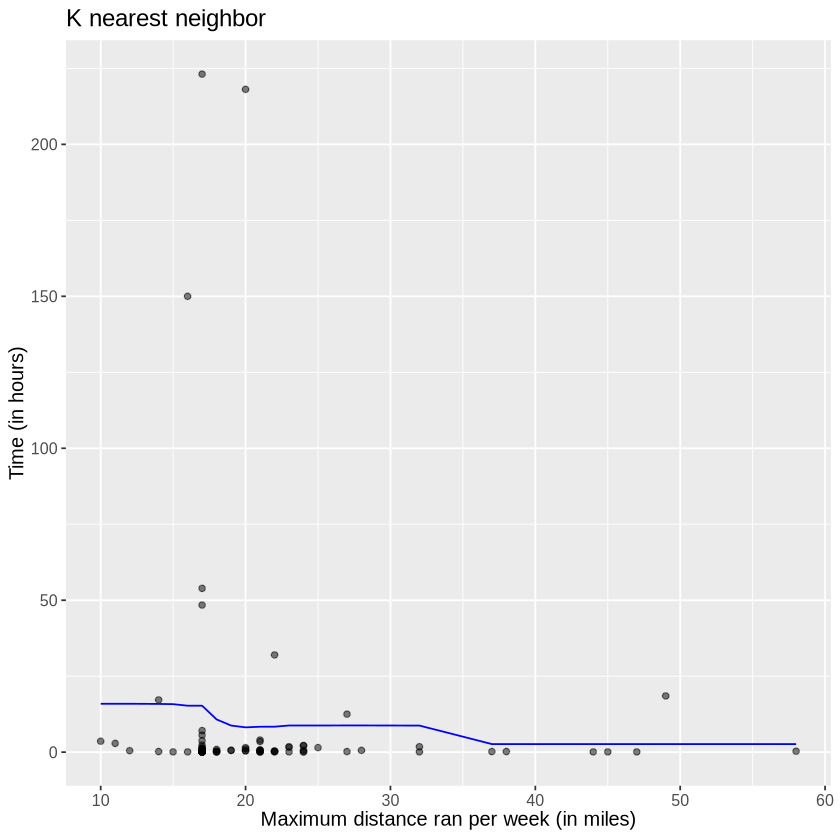

In [29]:
set.seed(2019) # DO NOT CHANGE

options(repr.plot.width = 7, repr.plot.height = 7)

minecraft_training <- minecraft_training |> drop_na(Age)
minecraft_preds <- minecraft_best_fit |>
    predict(minecraft_training)|>
        bind_cols(minecraft_training)

minecraft_plot <- minecraft_preds |>
    ggplot(aes(x= Age, y= played_hours)) +
           geom_point(alpha= 0.5) +
             geom_line(aes(y = .pred),color = "blue")+
           labs(x="Maximum distance ran per week (in miles)", y= "Time (in hours)", title = "K nearest neighbor")+
               theme(text= element_text(size= 12))
           
minecraft_plot

In [13]:
minecraft_wrangled

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Veteran,FALSE,71453e425f07d10da4fa2b349c83e73ccdf0fb3312f778b35c5802c3292c87bd,0.3,Pascal,Male,22
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA
